In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Define te sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [2]:
#Loss function : Log likelihood
def compute_loss(y, hx):
    return -np.mean(y * np.log(hx) + (1-y) * np.log(1 - hx))

In [3]:
#Gradient of the loss
def compute_gradient(X, y, hx):
    return np.dot(X.T, (hx - y)) / y.shape[0]

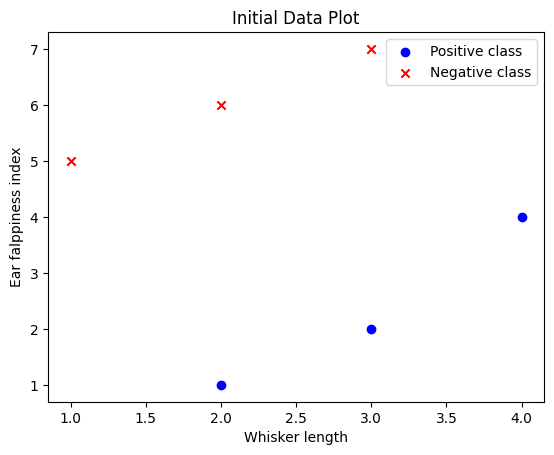

In [4]:
#Dataset
X = np.array([
    [2,1],
    [3,2],
    [4,4], #Positive points
    [1,5],
    [2,6],
    [3,7]   #Negative points
])
y = np.array([1,1,1,0,0,0]) #Labels

#Plot initial data 
plt.scatter(X[:3,0], X[:3,1], color='blue', marker='o', label='Positive class')
plt.scatter(X[3:,0], X[3:,1], color='red', marker='x', label='Negative class')
plt.xlabel('Whisker length')
plt.ylabel('Ear falppiness index')
plt.legend()
plt.title('Initial Data Plot')
plt.show()

In [8]:
#Logistic regression model
def logistic_regression(X, y, learning_rate=0.01, num_iterations=100):
    #Add intercept term to X
    X = np.hstack((np.ones((X.shape[0], 1)), X))

    #Initialize weights
    weights = np.zeros(X.shape[1])

    #Gradient descent
    for i in range(num_iterations):
        z = np.dot(X, weights)
        hx = sigmoid(z)
        loss = compute_loss(y ,hx)
        gradient = compute_gradient(X, y , hx)
        weights -= learning_rate * gradient

        if i%10 == 0:
            plot_decision_boundary(X, y , weights, loss, i)
            print(f'Iteration {i}:Theta={weights}, Loss={loss}')

    return weights

In [9]:
#plotting function for decision boundary
def plot_decision_boundary(X, y, weights, loss, iteration):
    plt.scatter(X[:3,1], X[:3, 2], color='blue', marker='o', label='Positive class' if iteration == 0 else "")
    plt.scatter(X[3:, 1], X[3:, 2], color='red', marker='x', label='Negative class' if iteration == 0 else "")

    #Extend the x values a bit beyond the minimum and maximum values of the dataset
    x_values = np.array([np.min(X[:,1]) - 1, np.max(X[:,1]) + 1])
    y_values = -(weights[0] + weights[1] * x_values) / weights[2]
    plt.plot(x_values, y_values, "k")

    plt.xlim(x_values[0], x_values[1])
    plt.ylim(np.min(X[:,2]) - 1, np.max(X[:, 2]) + 1)
    plt.xlabel('Whisker length')
    plt.ylabel('Ear flappiness index')
    plt.title(f"Decision boundary at iteration {iteration}\nLoss:{loss}")
    if iteration == 0:
        plt.legend()
    plt.show()


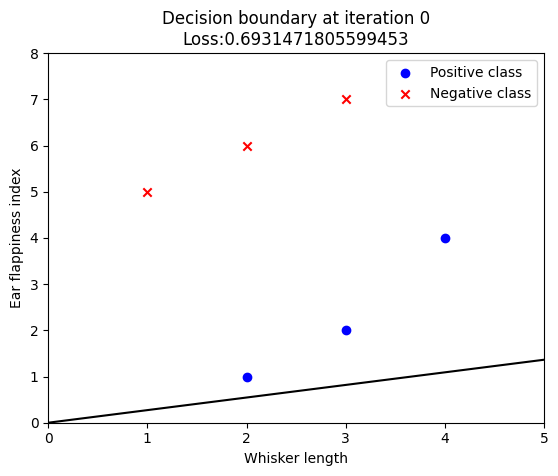

Iteration 0:Theta=[ 0.          0.0025     -0.00916667], Loss=0.6931471805599453


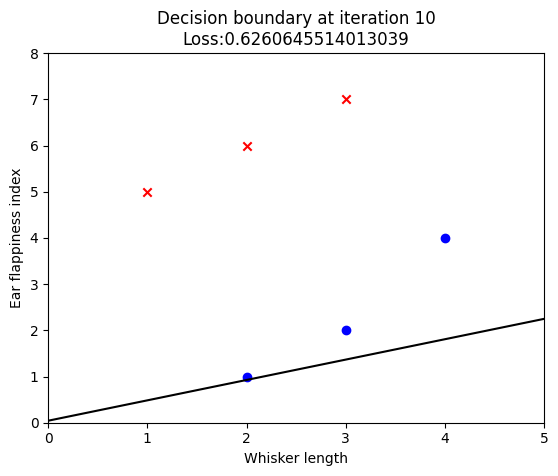

Iteration 10:Theta=[ 0.00351898  0.03583314 -0.08124515], Loss=0.6260645514013039


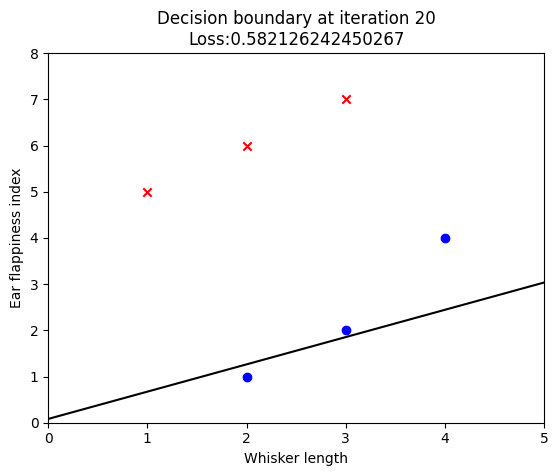

Iteration 20:Theta=[ 0.0107534   0.07750049 -0.13121449], Loss=0.582126242450267


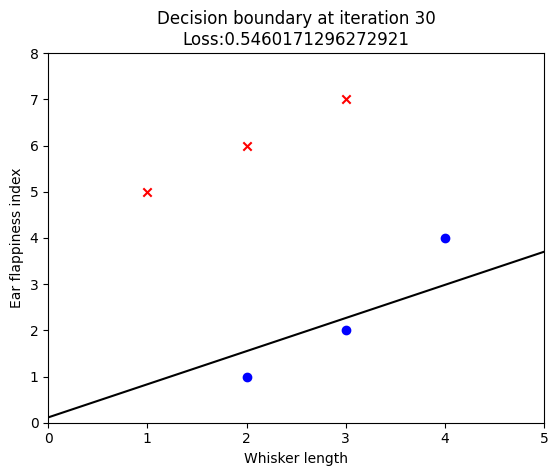

Iteration 30:Theta=[ 0.01952555  0.12200009 -0.17007813], Loss=0.5460171296272921


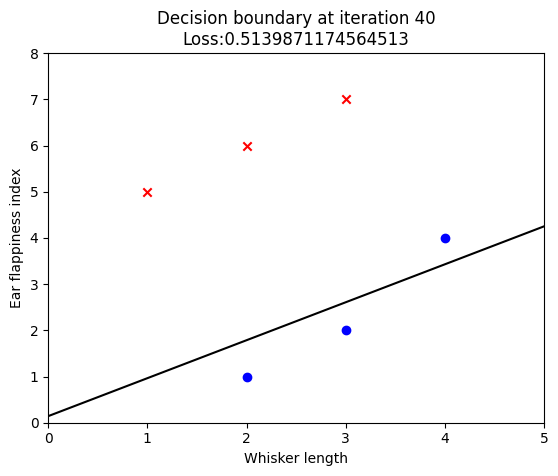

Iteration 40:Theta=[ 0.02882972  0.16681759 -0.20296236], Loss=0.5139871174564513


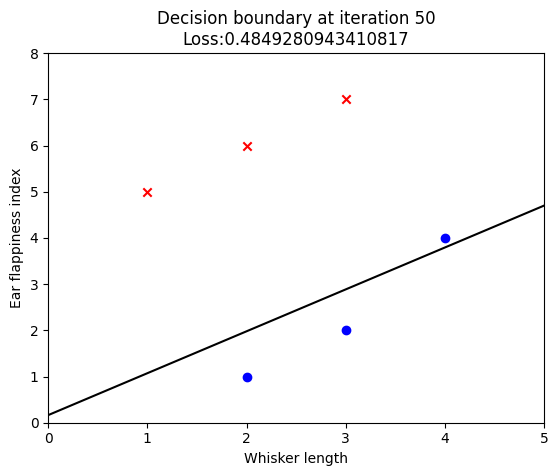

Iteration 50:Theta=[ 0.03819345  0.21079708 -0.23234289], Loss=0.4849280943410817


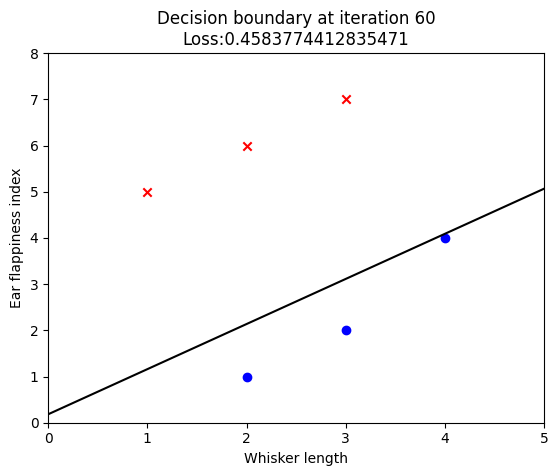

Iteration 60:Theta=[ 0.04739475  0.25342232 -0.25946218], Loss=0.4583774412835471


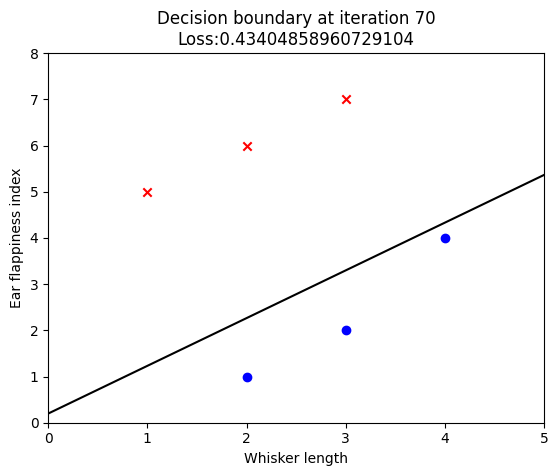

Iteration 70:Theta=[ 0.05633317  0.29448797 -0.28496725], Loss=0.43404858960729104


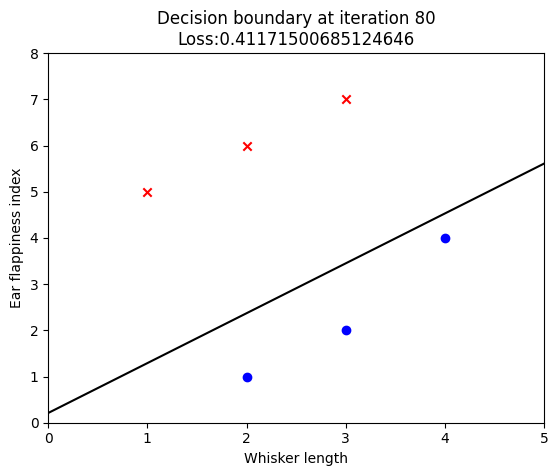

Iteration 80:Theta=[ 0.0649683   0.33394185 -0.30920989], Loss=0.41171500685124646


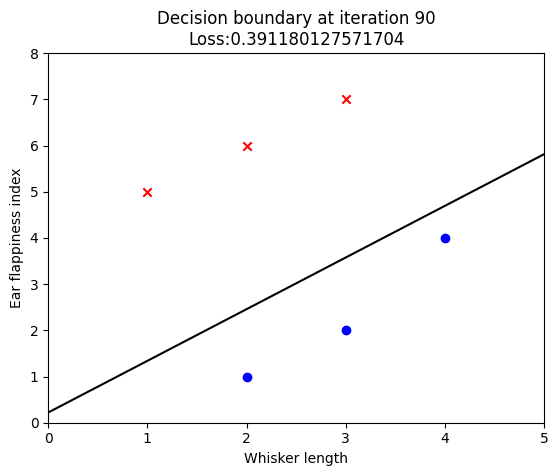

Iteration 90:Theta=[ 0.07328952  0.37180678 -0.33239254], Loss=0.391180127571704


In [10]:
#Training the model
weights = logistic_regression(X, y)

So It took 70 iterations to get our optimal decision boundary, the reason it took soo many iterations is the very low learning rate.

If we increase the learning rate to 0.1 from 0.01 then optimal decision boundary can be get after 6 iterations only.

Thats the importance of learning rate!